In [3]:
print("?")

?


In [4]:
import  numpy as np
import random
import time
#Setting states and actions
states =['Low', 'Medium', 'High']
actions=['Green_NS','Green_EW']
#Initializing Q-table
Q=np.zeros((3,2))
# Setting Hyperparameters
alpha=0.1
gama=0.9
epsilon=0.2
episodes=100 


In [5]:
def get_reward(traffic, action):
    if traffic=="High" and action=="Green_NS":
        return 10
    elif traffic=="Low" and action=="Green_EW":
        return 10
    else:
        return -5

In [24]:
for episode in range(episodes):
    state_index = random.randint(0,2)
    traffic = states[state_index]
    if random.uniform(0,1) < epsilon:
       action_index = random.randint(0,1)
    else:
        action_index = np.argmax(Q[state_index])
    reward=get_reward(traffic,actions[action_index])
    old_value=Q[state_index][action_index]
    next_max=np.max(Q[state_index])
    new_value=old_value + alpha*(reward + gama*next_max - old_value)
    Q[state_index,action_index]=new_value
    
print("Trained Q-table:")
print(Q)

Trained Q-table:
[[ 83.56758604  99.52841637]
 [-48.01384828 -48.0013802 ]
 [ 99.70889607  83.86722943]]


In [108]:
print("Traffic Signal Simulation:")
for i in range(5):
    state_index=random.randint(0,2)
    traffic=states[state_index]
    best_action_index=np.argmax(Q[state_index])
    print("Traffic Density",traffic)
    if actions[best_action_index]=="Green_NS":
        print("Signal:North-South GREEN")
    else:
        print("Signal: East West GREEN")
    time.sleep(1)

Traffic Signal Simulation:
Traffic Density Medium
Signal: East West GREEN
Traffic Density Medium
Signal: East West GREEN
Traffic Density Low
Signal: East West GREEN
Traffic Density Low
Signal: East West GREEN
Traffic Density High
Signal:North-South GREEN


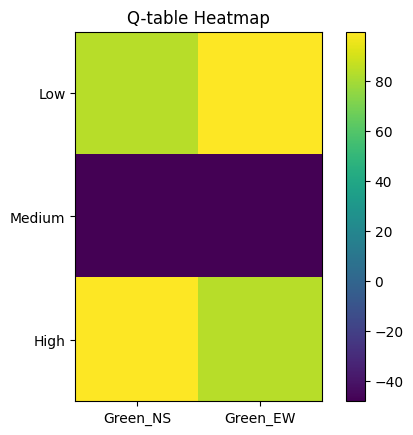

In [113]:
#visualization 
import matplotlib.pyplot as plt
plt.imshow(Q, cmap='viridis')
plt.colorbar()
plt.xticks([0,1], actions)
plt.yticks([0,1,2], states)
plt.title("Q-table Heatmap")
plt.show()



